© 2026 by Tamás Takács is licensed under CC BY-NC-SA 4.0. To view a copy of this license, visit https://creativecommons.org/licenses/by-nc-sa/4.0/

English translation managed by Tamás Takács. The translation was produced with AI assistance.

#Needle in a Haystack

**Import the notebook into Colab and work on it there!**


**Contestant's name:**

## Introduction

An important expectation towards language models is that they should be able to find the information relevant to a given question even within a long text file. Imagine, for example, that we want to ask a question about a piece of legislation hundreds of pages long, or about a complicated codebase of several thousand lines, where the answer can be given by finding a specific paragraph or function. We would like the model to find it (a) regardless of the length of the full document and (b) regardless of where within the document the information is located.

To test this ability systematically, Greg Kamradt devised a test that became famous as the [*Needle in a Haystack* (NIAH)](https://github.com/gkamradt/LLMTest_NeedleInAHaystack) test. The essence of the test is that we hide some piece of information (the needle) somewhere in a long document (the haystack), and then ask the model a question that it can only answer correctly based on the hidden information.

This problem set was inspired by the needle in a haystack test: there will be needles (messages) hidden inside haystacks (random strings), but we will be dealing with somewhat simplified versions of the problem.

## The subtasks

This task consists of several subtasks, some of which require the use of pytorch, others the use of the Mistral API. You may pick and choose freely among the subtasks, but we recommend that you work roughly in order within each category, since that is how the tasks were written.

### Pytorch tasks (`55 + 30 x project`):
1. ` 5 points` Compute the value of the loss function (pytorch)
1. `10 points` Compute the probability of false negative data points (math)
1. ` 5 points` Improve the training code (pytorch, algorithms)
1. ` 5 points` Evaluate the model on longer inputs (pytorch, matplotlib)
1. `10 points` Visualize what the RNN attends to (pytorch, gradients, matplotlib)
1. ` 5 points` Try out other RNN architectures (pytorch, architectures, matplotlib)
1. ` 5 points` Can the task be solved with a convolutional network? (pytorch, convolution)
1. `10 points` Implement a convolutional network (pytorch, convolution)
1. `30 points` **Freely interpretable mini-project** (you decide what to do)

### Mistral API tasks (`35 + 30 x project`)
1. ` 5 points` Design a natural-language "needle in a haystack" test (design)
1. `10 points` Implement the test you designed (Mistral API, matplotlib)
1. ` 5 points` Design a coding "needle in a haystack" test (design)
1. `10 points` Implement the test you designed (Mistral API, matplotlib)
1. ` 5 points` Compare the Mistral 7B and Mixtral 8x7B models (Mistral API)
1. `30 points` **Freely interpretable mini-project** (you decide what to do)



# Pytorch tasks

The pytorch tasks were inspired by the needle in a haystack test, but they differ from it in a few aspects and are simpler:
* **this time we train the models:** here we will not be testing pre-trained models, but training our own models on a training dataset created specifically for this purpose.
* **binary classification:** our own models will not be generative language models (like ChatGPT or Mistral), but will solve a simple binary classification problem: the model's input is text, its output is a single probability: it decides whether there is a needle in the input haystack or not.
* **binary strings:** so that our models can be as simple as possible, our texts will be binary 0/1 strings.

## The data we will be working with

The function below creates a `TensorDataset` object containing the binary strings we will work with. The docstring describes how it can be used.

In [ ]:
# @title Defining the dataset

import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

def get_binary_dataset(num_datapoints : int,
                       needle_length : int=20,
                       haystack_length : int=20) -> TensorDataset:
  '''
  Creates a labelled dataset of `num_datapoints` binary sequences. Each sequence
  is of total length `needle_length + haystack_length`. Positive examples have
  a needle string of length `needle_length` embedded starting at a random
  location within the string, surrounded by random 0s and 1s. The needle itself
  is a binary string of alternating 1s and 0s. Negative examples are completely
  random bitstrings of length `needle_length + haystack_length`. They may
  contain a needle by chance, although the probability of this is small as the
  `needle_legth` increases.

  The returned dataset contains positive examples first, followed by negatives.
  When using minibatch-SGD, the dataset has to be shuffled before broken into
  minibatches.

  Attributes
  ----------
  num_datapoints : int
    Number of datapoints to be generated. Half of the datapoints will be
    positive, the rest negative. If `num_datapoints==1` then the dataset will
    contain a single positive example.
  needle_length : int
    Length of the needle string
  haystack_length : int
    Number of haystack bits in the sequence in addition to the needle sequence.

  Returns
  -------
  torch.utils.data.TensorDataset
    Pytorch dataset containing the strings and their binary labels.
  '''
  num_positives = num_datapoints - num_datapoints // 2
  y = np.array([[1.0]]*num_positives + [[0.0]]*(num_datapoints - num_positives))
  X = np.random.randint(2, size=(num_datapoints, needle_length + haystack_length))
  needle = np.array((needle_length//2)*[1.0, 0.0])
  for i in range(num_positives):
    j = np.random.randint(haystack_length)
    X[i, j:(j+needle_length)] = needle
  X = torch.tensor(X, dtype=torch.float)[:, :, None]
  y = torch.tensor(y)
  return TensorDataset(X, y)

Let's see what this dataset looks like! Below I generate $100$ positive and $100$ negative samples, each of length $40$. This results in a matrix of size $200\times40$, which I display. In the positive samples you will be able to see the embedded 20-character-long `10101010101010101010` "needle", at a random position within each haystack (row).

*Note:* Here I use the `spy` function, which is meant for displaying sparse matrices, in which there are many zeros and we are only interested in where the non-zero elements are.

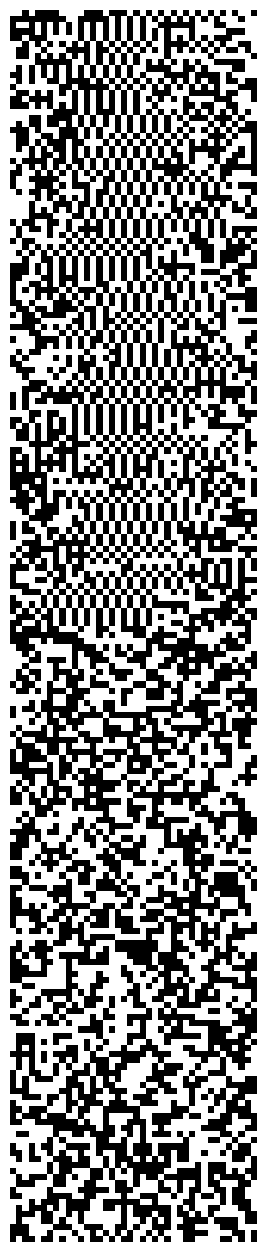

In [ ]:
# @title Plotting the samples
from matplotlib import pylab as plt

ds = get_binary_dataset(200,
                        needle_length=20,
                        haystack_length=20)

plt.figure(figsize=(4, 16))
plt.spy(ds.tensors[0][:, :, 0].numpy())
plt.axis('off');

## The simplest RNN model

Now we are going to build a simple RNN-based classifier for classifying binary sequences. We feed the sequence into the RNN, then extract the hidden state activations at the end of the sequence, and finally apply a linear transformation to compute the classifier's output.

An RNN module returns two outputs, as the [documentation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) also explains. We will also need a layer that selects the second output — the hidden state activation at the end of the sequence — and then permutes and flattens (`flatten`) it so that it can be the input of the linear layer.

*Note:* By applying an additional `sigmoid`, the classifier's output can be turned into a probability, similarly to how `softmax` works. We will not make the sigmoid part of the network, since this way training will be numerically more stable.

In [ ]:
# @title Definition of the RNN classifier

from torch.nn import RNN, Linear, Sequential

class extract_last_cell(torch.nn.Module):
  '''Pytorch module which extracts and flattens the last hidden state of an RNN.
  '''
  def forward(self,x):
    _ , out = x
    return out.permute(1,0,2).flatten(start_dim=1)

def get_basic_RNN_classifier():
  return Sequential(
    RNN(input_size=1, hidden_size=20, num_layers=2, batch_first=True),
    extract_last_cell(),
    Linear(in_features = 20*2, out_features=1)
  )

## Subtask 1\.: Compute the value of the loss function

Compute the logarithmic loss (i.e. the cross entropy loss or log loss) of the untrained network, initialized with random weights, on minibatches drawn from the dataset defined above.

*Tips:*
* you can use the [`pytorch/utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) class to sample minibatches from the data.
* and/or you can also access the contents of the `TensorDataset` directly using the `tensors` attribute.
* use the [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) class or the [`torch.nn.functional.binary_cross_entropy_with_logits`](https://pytorch.org/docs/stable/nn.functional.html) function. I recommend reading through the documentation.

*5 points*

### Your solution

Use this text cell and the code cell below, or add further cells if you find it necessary.

## Subtask 2\.: Computing the false negative probability

As the documentation also mentions, there is a negligible probability that the needle sequence happens to occur in a negative datapoint as well. In such a case we can call this datapoint a false negative, because although it contains a needle, it is labelled as negative.

Let the length of the needle be $k$, and the length of the whole sequence $k+l$. Compute the probability that a negative sample (a binary sequence of length $k+l$, in which $0$ and $1$ occur with equal probability) is in fact positive, that is, contains the $k$-long $010101\ldots01$ sequence. Describe your reasoning. Your solution may be a formula, or even a python function whose parameters are $k$ and $l$.

*Tip:*
* If you know it, use LaTeX expressions, which you can write between dollar signs

*10 points*

### Your solution

## The training code

We used the `ignite` framework to write the training code below. First of all, let's install the python module. The code itself is rather long, but it is in fact very simple. Below the code we explain some of its components.


In [ ]:
# @title Installing `torch-ignite`
!pip install pytorch-ignite

In [ ]:
# @title Original training code
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_basic(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  '''Fits a pytorch model to the training dataset using stochastic gradient
  descent and tracks progress on a test set.

  Arguments
  ---------
  model : pytorch.nn.Module
    pytorch model that can be evaluated on input tensor in the dataset, and
    returns a tensor that matches the shape of the output tensor.
  training_dataset : pytorch.util.data.Dataset
    used to train the model
  test_dataset : pytorch.util.data.Dataset
    used to evaluate the performance of the model at the end of each epoch

  Retuns
  ------
  pytorch.nn.Module
    the model after training
  '''

  train_loader = DataLoader(
      training_dataset,
      batch_size=100,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=1000,
      shuffle=False,
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=5)

  return model

The code above may look long and complicated, but that is because we want ignite to log the progress of the training process in detail.

Ignite uses Python decorators (such as `@trainer.on(Events.EPOCH_COMPLETED))`. In Ignite, these decorators are used to register functions that get called when various events occur during training. For example, `@trainer.on(Events.ITERATION_COMPLETED(every=10))` tells ignite to execute the function below it every time 10 iterations have been completed.

The code above is largely an adaptation of the example code found in the [ignite documentation](https://pytorch-ignite.ai/tutorials/beginner/01-getting-started/); you do not need to understand it in detail right now.

So let's dive in and use our training loop to train a classifier on the binary dataset we created:

In [ ]:
# @title First attempt at training

ds_train = get_binary_dataset(5000, needle_length=10, haystack_length=10)
ds_test = get_binary_dataset(1000, needle_length=10, haystack_length=10)
rnn_classifier = get_basic_RNN_classifier()

fit_model_basic(rnn_classifier, ds_train, ds_test)

Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.70
Training Results - Epoch: 1  Avg accuracy: 0.50 Avg loss: 0.69
Validation Results - Epoch: 1  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.70
Epoch[2] Loss: 0.70
Training Results - Epoch: 2  Avg accuracy: 0.51 Avg loss: 0.69
Validation Results - Epoch: 2  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.70
Epoch[3] Loss: 0.69
Training Results - Epoch: 3  Avg accuracy: 0.51 Avg loss: 0.69
Validation Results - Epoch: 3  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[4] Loss: 0.70
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.70
Epoch[4] Loss: 0.69
Training Results - Epoch: 4  Avg accuracy: 0.52 Avg loss: 0.69
Validation Results - Epoch: 4  Avg accuracy: 0.51 Avg loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5]

Sequential(
  (0): RNN(1, 20, num_layers=2, batch_first=True)
  (1): extract_last_cell()
  (2): Linear(in_features=40, out_features=1, bias=True)
)

## Subtask 3\.: Improve the training code

Well, it seems our training function is not very successful, since even by the end of training it only reaches barely more than 50% accuracy, so it is essentially no better than guessing with a coin flip.

With small changes, however, results above 90% can be achieved.

Improve the training code. Below the task we have copied the same function as before, under the name `fit_model_improved`. You will use this function in the following tasks. Make minimal changes to it so that training becomes more successful.
* Add extra arguments to the function that let you set important training parameters (such as the learning rate)
* You may replace components, for example you can choose a different optimization algorithm
* Document your changes, and the method by which you found better parameters.
* Demonstrate that the new version works better

*5 points*


### Your solution

Rewrite the contents of the code cell below, and add further code and text cells.

In [ ]:
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_improved(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  '''Fits a pytorch model to the training dataset using stochastic gradient
  descent and tracks progress on a test set.

  Arguments
  ---------
  model : pytorch.nn.Module
    pytorch model that can be evaluated on input tensor in the dataset, and
    returns a tensor that matches the shape of the output tensor.
  training_dataset : pytorch.util.data.Dataset
    used to train the model
  test_dataset : pytorch.util.data.Dataset
    used to evaluate the performance of the model at the end of each epoch

  Retuns
  ------
  pytorch.nn.Module
    the model after training
  '''

  train_loader = DataLoader(
      training_dataset,
      batch_size=100,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=1000,
      shuffle=False,
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=5)

  return model

## Subtask 4\.: Evaluate the model on longer sequences

We trained our model above with fixed-length strings, but an RNN is able to process input of any length.
* Try out whether the successfully trained model can also find the needle in test sequences longer than the training data?
* Document your results with a figure, and also evaluate them in words (briefly, in 1-2 sentences).

*5 points*

### Your solution

## Subtask 5\.: Try out other RNN architectures

Try out other, commonly used RNN architectures that were also mentioned in the preparatory course. Compare in a single figure how these perform, especially on the longer sequences examined in Subtask 4. Interpret the results and give a short (1-3 sentence) explanation.

*5 points*

### Your solution

## Subtask 6\.: Illustrate what the model pays attention to

In this part of the task we want to understand which part of its input the model bases its decision on. This problem is also commonly called attribution.

In the case of RNNs, the derivative of the outputs with respect to the inputs, and the magnitude of those derivatives, can provide information about this. This method is used by [this distill article](https://distill.pub/2019/memorization-in-rnns/) as well, and the topic also came up in the preparatory course, as well as in [Feri's notes](https://hackmd.io/QrkitKUITGySbLAzkakzYw), where it illustrates the vanishing gradients problem.

* compute the gradient of the model's output with respect to the inputs
* plot this in such a way that it shows which inputs the model pays attention to
* using your solutions to the other subtasks, compare two situations (say, two models, or inputs of different lengths)
* draw a conclusion, and describe what you observe (in 3-5 sentences).

**Tip:**
* the task can be solved with at most 5-10 lines of pytorch code.

*10 points*

### Your solution

## Subtask 7\.: Can it be solved with convolution?

Argue in 3-5 sentences whether you think the task can be solved with a convolutional network.
* How large a convolutional network would be needed, and with what structure? How many layers, how many filters, how large should the filters be, are stride and padding needed?
* Which pytorch layers would you use?
* Do you expect it to work better or worse than an RNN?

*5 points*

### Your solution

## Subtask 8\.: Train a convolutional network

Based on the observations described in the previous subtask, implement and train a CNN, then evaluate it in comparison with the RNNs. Document what you observed (in 2-4 sentences).

*Tips*:
* since we are not working with images, different pytorch layers may be useful now than the ones we saw earlier. It is worth taking a good look around among the [convolutional](https://pytorch.org/docs/stable/nn.html#convolution-layers) and [adaptive pooling](https://pytorch.org/docs/stable/nn.html#pooling-layers) layers. And there may also be utility functions that are useful
* reading the documentation also helps in getting the dimensions/shapes of the tensors right. Useful utility layers such as `nn.Flatten` or `nn.Unflatten` may also come in handy.
* don't overcomplicate it, this is a simple task, the most minimal solution earns full marks.

*10 points*

### Your solution

## 9. pytorch mini-project: Independent exploration

If you have solved most of the other subtasks, we now leave it up to you what further additions you would like to implement related to the topic.
Here are a few examples:
* Making the data more complex: say, samples drawn from a non-binary, discrete alphabet, or multiclass (several kinds of needle)
* a multi-component needle where, say, the presence of two substrings has to be detected at the same time.
* Something like a Pointer Network: don't just say whether there is a needle, but also what its starting position is.
* Implementing a transformer architecture
* A generative or sequence-to-sequence model
* Needle in a haystack, computer vision edition

Each mini-project (you may submit more than one, as long as they are clearly distinct) is worth a maximum of *30 points*. The characteristics of a 30-point project:
* **motivation and creativity:** an interesting, creative project, good motivation, a clear description of the hypotheses-questions-goals, references to the literature where relevant
* **implementation:** non-trivial work that demonstrates technical proficiency, correct implementation, good choice of tools, compact and readable code
* **evaluation and conclusions:** fair and detailed evaluation, excellent use of figures (captions, labels, etc.), concise but to-the-point conclusions.

*30 points/mini-project*

# Mistral API tasks

In these tasks you will test Mistral AI's language models via the API, using various Needle in a Haystack (NIAH) tests of your own design.

## Testing the Mistral API

Before the competition we asked you to obtain an API key from Mistral and add it to Colab. If you have done so, the code below should run. This code also shows how you can converse with the model using the API (application programming interface). You can find the API documentation [here](https://docs.mistral.ai/capabilities/completion/).

In [ ]:
!pip install mistralai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.3 MB/s eta 0:00:00


In [ ]:
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage
from google.colab import userdata

model = 'open-mistral-7b'
api_key = userdata.get('MISTRAL_API_KEY')
client = MistralClient(api_key=api_key)

messages = [
    ChatMessage(role="user", content="What is the best French cheese?")
]

# No streaming
chat_response = client.chat(
    model=model,
    messages=messages,
)

print(chat_response.choices[0].message.content)

The "best" French cheese can be quite subjective as it depends on personal taste. However, some of the most famous and widely appreciated French cheeses include:

1. Roquefort: A blue cheese made from sheep's milk. It's known for its strong, pungent flavor and crumbly texture.

2. Camembert de Normandie: A soft, creamy cow's milk cheese with a white rind. It's often served at room temperature and has a mild, earthy flavor.

3. Brie de Meaux: Another soft, creamy cow's milk cheese, but with a smooth, spreadable texture. It has a mild, slightly nutty flavor.

4. Comté: A hard, nutty-flavored cheese made from unpasteurized cow's milk. It's often used in cooking and on sandwiches.

5. Reblochon: A soft, washed-rind cow's milk cheese from the Rhône-Alpes region. It's often used in dishes like fondue and tartiflette.

6. Munster: A soft, smelly cheese with a washed rind. It's known for its strong, spicy flavor.

7. Époisses de Bourgogne: A soft, smelly cheese with a washed rind. It's known f

## 1\. Subtask: Design a NIAH test

Design a simplified needle in a haystack (NIAH) test that evaluates the natural (English) language capabilities of the `Mistral open 7B` model. In this test we insert some short piece of information into relatively long English texts, then ask the model a question that it can answer correctly based on the inserted information. Plan as precisely as possible what text you will use, how you will use the API, how you will evaluate the results, and what performance you expect from the model. Document all of this in 5-10 sentences. The perfect solution is a concise specification based on which the test can be reproduced and carried out as accurately as possible.

*Tips:*
* using the [NIAH github repository](https://github.com/gkamradt/LLMTest_NeedleInAHaystack) as-is is not allowed, but it can give you ideas for solving the tasks.
* the [torchtext](https://pytorch.org/text/stable/index.html) library contains several easily accessible text corpora.

*5 points*

### Your solution

Use a text cell.

## 2\. Subtask: Implement the test

Now implement the test you designed in the previous subtask, using the Mistral API. Ideally, also produce a figure of the evaluation results, document your solution in a few sentences, and evaluate the results.

* For the sake of consistency, use the Mistral 7B open source model!
* Keep the number of input tokens below roughly 1000 tokens per message, and do not use more than about 10,000,000 tokens in total.

*10 points*

### Your solution

Use code and text cells!

## 3\. Subtask: Design a coding NIAH test

Now, similarly to subtask 1, design a NIAH test, but instead of English language skills, test capabilities related to coding/formal languages. So this time use programming language data, or algorithmically generated formal languages. Document it in the same way as in the first subtask.

*5 points*

### Your solution

## 4\. Subtask: Implement the test

Now implement the coding NIAH test you designed in the previous subtask, using the Mistral API. Ideally, also produce a figure of the evaluation results, document your solution in a few sentences, and evaluate the results.

* For the sake of consistency, use the Mistral 7B open source model this time as well!
* Keep the number of input tokens below roughly 1000 tokens as before, and do not use more than about 10,000,000 tokens in total.

*10 points*

### Your solution

## 5\. Subtask:

Compare the Mistral 7B and Mixtral 8x7B open source models on the NIAH tests. Write 3-5 lines about the results.

*5 points*

## Your solution

## 6\. Mistral mini-project: Independent exploration

If you have solved most of the other Mistral subtasks, it is now up to you to decide what further extensions you would like to implement on this topic.
Here are a few examples:
* Making the test more complex: say there are two needles that have to be combined to arrive at the correct solution
* Using the Mistral API's embedding endpoint in some creative way, in the needle in a haystack context.
* Successful or unsuccessful detection of syntax errors in C++ code as a function of the code length and the position of the error.

Each mini-project is worth max *30 points* (you may submit more than one, they just have to be clearly distinct). Characteristics of a 30-point project:
* **motivation and creativity:** an interesting, creative project, good motivation, clear description of hypotheses-questions-goals, references to the literature where relevant
* **implementation:** non-trivial work that demonstrates technical proficiency, correct implementation, good choice of tools, compact and readable code
* **evaluation and conclusions:** fair and detailed evaluation, excellent use of figures (captions, labels, etc.), concise but to-the-point conclusions.

*30 points/mini-project*